# Transfer Learning for Image Classification using VGG16 and ResNet50

### Intel Image Classification Dataset

**Objective:** Apply Transfer Learning using pre-trained **VGG16** and **ResNet50** convolutional neural networks on the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification), and compare their performance on a 6-class natural scene classification task (`buildings`, `forest`, `glacier`, `mountain`, `sea`, `street`).

---

## Table of Contents
1. Environment and Setup
2. Dataset Exploration
3. Data Cleaning
4. Data Preprocessing
5. Background: Transfer Learning, VGG16 & ResNet50
6. Model 1 — VGG16 Transfer Learning
7. Model 2 — ResNet50 Transfer Learning
8. Evaluation
9. Visualizations
10. Performance Comparison
11. Prediction on New Images
12. Conclusion

---


## 1. Environment and Setup

This notebook uses **TensorFlow** and **Keras** exclusively for building, training and evaluating the deep learning models.

In [1]:
# ------------------------------------------------------------
# Core imports
# ------------------------------------------------------------
import os
import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Scikit-learn for evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Imports successful.")


2026-06-21 13:18:24.590663: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782047904.821169      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782047904.883061      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782047905.445942      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782047905.445981      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782047905.445983      58 computation_placer.cc:177] computation placer alr

Imports successful.


## 2. Dataset Exploration

The **Intel Image Classification** dataset contains ~25,000 natural scene images (150x150 px, RGB) belonging to **6 classes**:

| Class | Description |
|---|---|
| `buildings` | Urban buildings / architecture |
| `forest` | Forest scenes |
| `glacier` | Glaciers / icy landscapes |
| `mountain` | Mountain landscapes |
| `sea` | Sea / ocean scenes |
| `street` | Street scenes |

the dataset is  `/kaggle/input/intel-image-classification/` and is pre-split into:
* `seg_train/seg_train/<class>/` — training images
* `seg_test/seg_test/<class>/` — test images
* `seg_pred/seg_pred/` — unlabeled images (for inference demos only) 


In [2]:
DATASET_ROOT_CANDIDATES = [
    "/kaggle/input/intel-image-classification",
]

dataset_root = None
for candidate in DATASET_ROOT_CANDIDATES:
    if os.path.exists(candidate):
        dataset_root = candidate
        break

if dataset_root is None:
    # Fallback: search /kaggle/input for any folder containing 'intel'
    for root, dirs, files in os.walk("/kaggle/input"):
        if "intel" in root.lower() and "seg_train" in os.listdir(root) if os.path.isdir(root) else False:
            dataset_root = root
            break

print(f"Detected dataset root: {dataset_root}")
print("\nFolder structure (depth-limited to keep output readable):\n")

MAX_DEPTH = 3
for root, dirs, files in os.walk(dataset_root):
    depth = root[len(dataset_root):].count(os.sep)
    if depth > MAX_DEPTH:
        dirs[:] = []  # stop descending further
        continue
    indent = "    " * depth
    print(f"{indent}{os.path.basename(root) or root}/")
    if depth == MAX_DEPTH:
        # Show only a file count at max depth to avoid flooding output
        print(f"{indent}    ... ({len(files)} files)")
        dirs[:] = []


Detected dataset root: /kaggle/input/datasets/puneet6060/intel-image-classification

Folder structure (depth-limited to keep output readable):

intel-image-classification/
    seg_train/
        seg_train/
            mountain/
                ... (2512 files)
            street/
                ... (2382 files)
            buildings/
                ... (2191 files)
            sea/
                ... (2274 files)
            forest/
                ... (2271 files)
            glacier/
                ... (2404 files)
    seg_pred/
        seg_pred/
    seg_test/
        seg_test/
            mountain/
                ... (525 files)
            street/
                ... (501 files)
            buildings/
                ... (437 files)
            sea/
                ... (510 files)
            forest/
                ... (474 files)
            glacier/
                ... (553 files)


In [3]:
# ------------------------------------------------------------
# Define and display the dataset paths used throughout the notebook
# ------------------------------------------------------------
TRAIN_DIR = os.path.join(dataset_root, "seg_train", "seg_train")
TEST_DIR  = os.path.join(dataset_root, "seg_test", "seg_test")
PRED_DIR  = os.path.join(dataset_root, "seg_pred", "seg_pred")

print(f"TRAIN_DIR : {TRAIN_DIR}  -> exists: {os.path.exists(TRAIN_DIR)}")
print(f"TEST_DIR  : {TEST_DIR}  -> exists: {os.path.exists(TEST_DIR)}")
print(f"PRED_DIR  : {PRED_DIR}  -> exists: {os.path.exists(PRED_DIR)}")

CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nClasses ({NUM_CLASSES}): {CLASS_NAMES}")


TRAIN_DIR : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train  -> exists: True
TEST_DIR  : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test  -> exists: True
PRED_DIR  : /kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred  -> exists: True

Classes (6): ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
# ------------------------------------------------------------
# Show number of images per class (train and test)
# ------------------------------------------------------------
def count_images_per_class(directory, class_names):
    counts = {}
    for cls in class_names:
        cls_dir = os.path.join(directory, cls)
        n = len([f for f in os.listdir(cls_dir)
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        counts[cls] = n
    return counts

train_counts = count_images_per_class(TRAIN_DIR, CLASS_NAMES)
test_counts  = count_images_per_class(TEST_DIR, CLASS_NAMES)

counts_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_images": [train_counts[c] for c in CLASS_NAMES],
    "test_images": [test_counts[c] for c in CLASS_NAMES],
})
counts_df["total"] = counts_df["train_images"] + counts_df["test_images"]
counts_df.loc["TOTAL"] = ["ALL", counts_df.train_images.sum(),
                           counts_df.test_images.sum(), counts_df.total.sum()]
counts_df


,class,train_images,test_images,total
0,buildings,2191,437,2628
1,forest,2271,474,2745
2,glacier,2404,553,2957
3,mountain,2512,525,3037
4,sea,2274,510,2784
5,street,2382,501,2883
TOTAL,ALL,14034,3000,17034


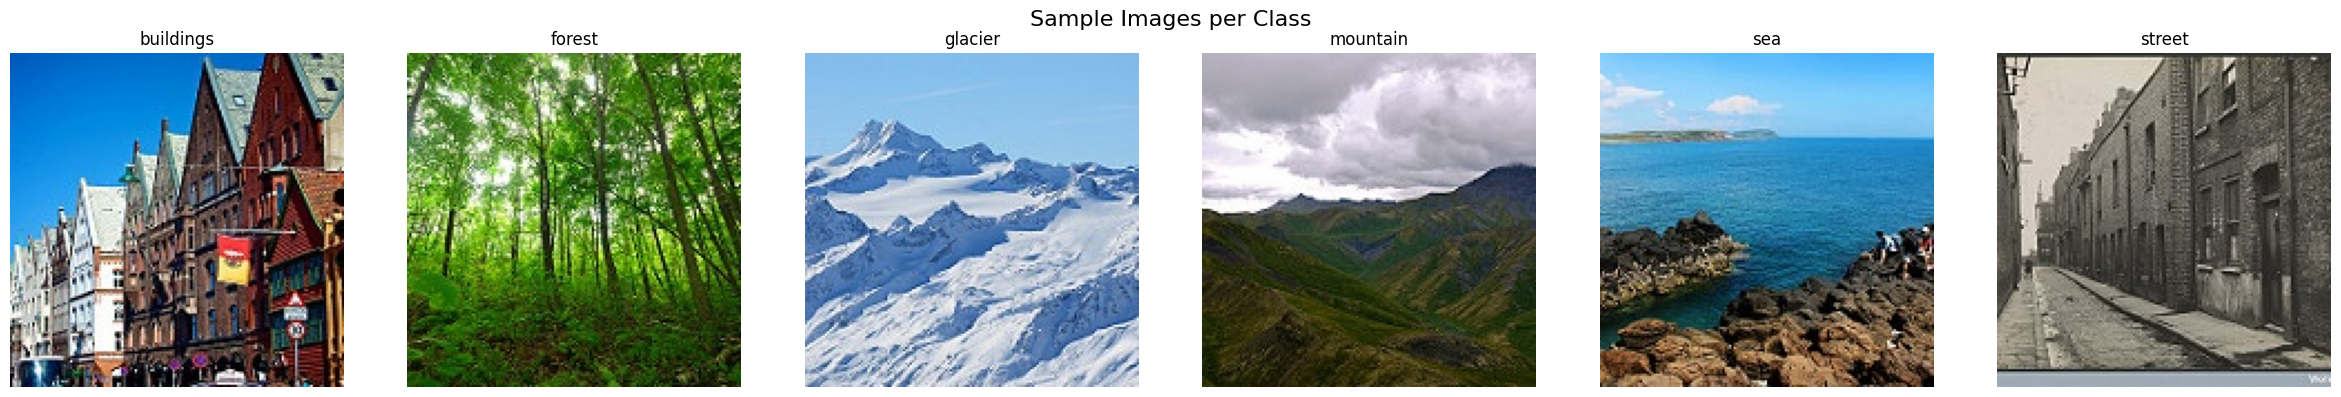

In [5]:
# ------------------------------------------------------------
# Visualize sample images from each class
# ------------------------------------------------------------
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(4 * NUM_CLASSES, 4))
for ax, cls in zip(axes, CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    sample_file = random.choice(os.listdir(cls_dir))
    img = Image.open(os.path.join(cls_dir, sample_file))
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Sample Images per Class", fontsize=16)
plt.tight_layout()
plt.show()


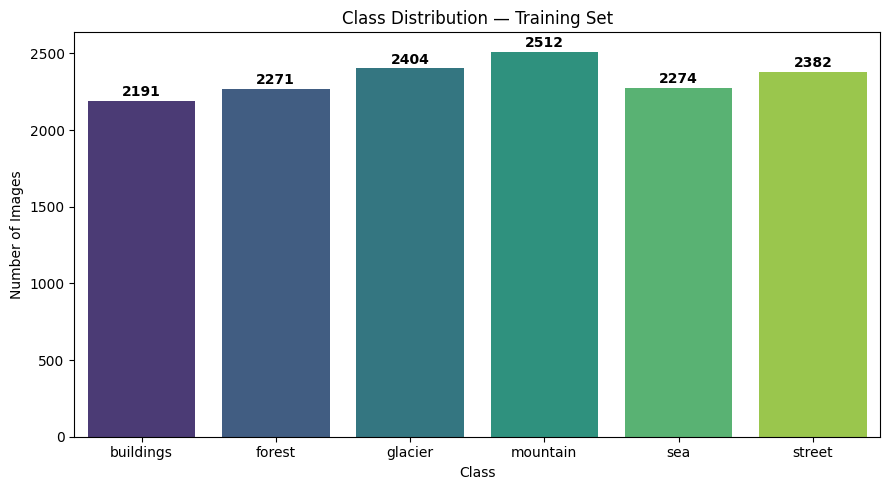

In [6]:
# ------------------------------------------------------------
# Class distribution bar chart (training set)
# ------------------------------------------------------------
plt.figure(figsize=(9, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), palette="viridis")
plt.title("Class Distribution — Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
for i, v in enumerate(train_counts.values()):
    plt.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Data Cleaning

Real-world image datasets occasionally contain corrupted, truncated, or unreadable files that can crash the data pipeline mid-training. Before building the `ImageDataGenerator` pipelines, we scan every image in the training and test directories, attempt to open and fully load each one with `PIL`, and **delete** any file that fails this check.


In [7]:
# ------------------------------------------------------------
# Detect and remove corrupted / unreadable images
# ------------------------------------------------------------
def find_and_remove_corrupted_images(directory, remove=True):
    corrupted_files = []
    for cls in os.listdir(directory):
        cls_dir = os.path.join(directory, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()  # quick structural check
                # Re-open and load fully (verify() leaves file in a state
                # that can't be reused for image processing)
                with Image.open(fpath) as img:
                    img.convert("RGB").load()
            except Exception:
                corrupted_files.append(fpath)

    if remove:
        for fpath in corrupted_files:
            try:
                os.remove(fpath)
            except OSError:
                pass

    return corrupted_files

print("Scanning training set for corrupted images...")
corrupted_train = find_and_remove_corrupted_images(TRAIN_DIR, remove=True)
print(f"Removed {len(corrupted_train)} corrupted file(s) from the training set.")

print("\nScanning test set for corrupted images...")
corrupted_test = find_and_remove_corrupted_images(TEST_DIR, remove=True)
print(f"Removed {len(corrupted_test)} corrupted file(s) from the test set.")

print(f"\nTotal corrupted files removed: {len(corrupted_train) + len(corrupted_test)}")
if corrupted_train or corrupted_test:
    print("Examples of removed files:", (corrupted_train + corrupted_test)[:5])


Scanning training set for corrupted images...
Removed 0 corrupted file(s) from the training set.

Scanning test set for corrupted images...
Removed 0 corrupted file(s) from the test set.

Total corrupted files removed: 0


## 4. Data Preprocessing

Both VGG16 and ResNet50 expect a fixed **224x224** RGB input. We use Keras's `ImageDataGenerator` to build efficient, on-the-fly data pipelines that:

* **Resize** every image to `224x224` (`target_size`).
* **Normalize** pixel values to the `[0, 1]` range (`rescale=1/255`).
* **Augment** the training data with:
  * Random **rotation** (±30°)
  * Random **zoom** (±20%)
  * Random **horizontal flip**
  * Small width/height shifts (helps generalization further)
* Automatically split the training directory into **training (80%)** and **validation (20%)** subsets via `validation_split`.
* Build a separate, **non-augmented** generator for the **test** set (only rescaling is applied — augmentation must never be applied to evaluation data).


In [8]:
# ------------------------------------------------------------
# Preprocessing / augmentation configuration
# ------------------------------------------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Training generator: rescaling + augmentation + train/val split
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,          # Normalize pixel values to [0, 1]
    rotation_range=30,            # Random rotation
    zoom_range=0.2,                # Random zoom
    horizontal_flip=True,          # Horizontal flip
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest",
    validation_split=VALIDATION_SPLIT,
)

# Test generator: rescaling ONLY (no augmentation, for fair evaluation)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="training",
    shuffle=True,
    seed=SEED,
)

val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    subset="validation",
    shuffle=False,
    seed=SEED,
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False,  # keep order for evaluation / confusion matrix
)

print(f"\nTraining samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
print(f"Test samples        : {test_generator.samples}")
print(f"Class indices       : {train_generator.class_indices}")


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.

Training samples   : 11230
Validation samples : 2804
Test samples        : 3000
Class indices       : {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


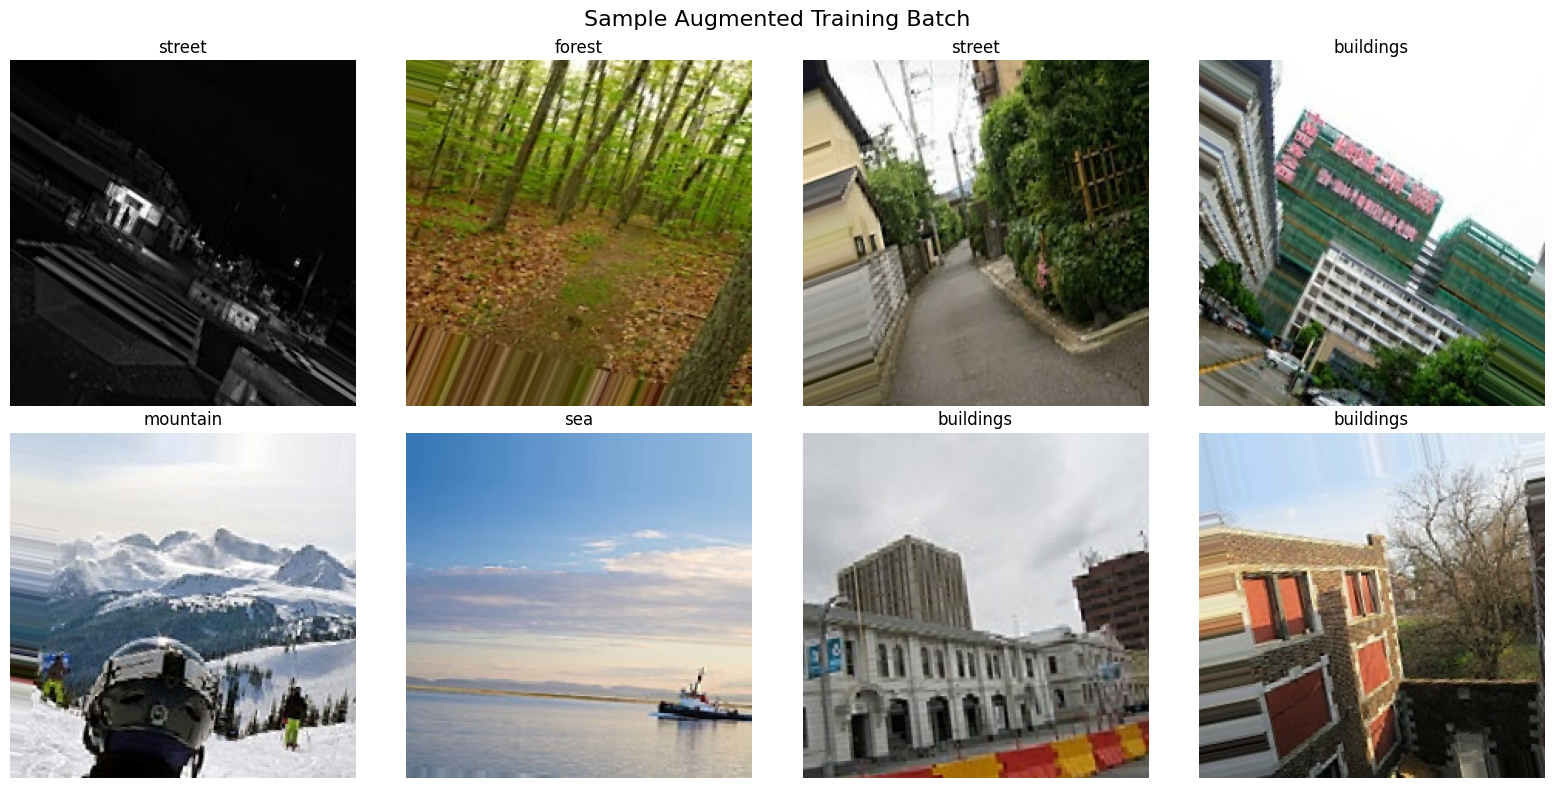

In [9]:
# ------------------------------------------------------------
# Visual sanity check: plot a batch of augmented training images
# ------------------------------------------------------------
sample_batch_x, sample_batch_y = next(train_generator)
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch_x[i])
    label_idx = np.argmax(sample_batch_y[i])
    ax.set_title(idx_to_class[label_idx])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Batch", fontsize=16)
plt.tight_layout()
plt.show()

# Reset generator iterator state before training
train_generator.reset()


## 5. Background: Transfer Learning, VGG16 & ResNet50

### What is Transfer Learning?
**Transfer Learning** is a deep learning technique where a model developed for one task (typically trained on a very large dataset, such as ImageNet's 1.2 million images across 1,000 classes) is **reused as the starting point** for a model on a second, related task. Instead of training a CNN from scratch — which requires huge amounts of data, compute, and time — we reuse the **convolutional feature extractor** of a pre-trained network (which has already learned general-purpose visual features such as edges, textures, shapes, and object parts) and attach a **new classification head** suited to our specific problem.

**Why pre-trained models are useful:**
* **Less data required** — our 6-class, ~14k-image dataset is far too small to train a deep CNN from scratch without severe overfitting.
* **Faster training** — only the new classification head (a few thousand to a few million parameters) needs to be trained, instead of tens of millions of convolutional weights.
* **Better generalization** — low- and mid-level features (edges, corners, textures, color blobs) learned on ImageNet transfer well to almost any natural-image task.
* **Lower compute cost** — freezing the convolutional base means far fewer gradients to compute during backpropagation.

In this notebook we apply the most common transfer-learning recipe: **feature extraction**, where the pre-trained convolutional base is **frozen** (its weights are not updated) and only a small custom classification head is trained on top of it.

### VGG16 Architecture

**VGG16** is a popular Convolutional Neural Network (CNN) that is known for its simple and easy-to-understand architecture.

* It uses multiple **3×3 convolution layers** to extract features from images.
* After a group of convolution layers, a **2×2 max-pooling layer** is used to reduce image dimensions.
* The original VGG16 model contains 16 layers and was trained on the ImageNet dataset.
* In this project, the original classification layers were removed and replaced with a custom classification head suitable for our dataset.
* Although VGG16 has a large number of parameters, it is widely used because of its strong feature extraction capabilities.

**Advantages:**

* Simple and easy to understand.
* Provides strong image features for transfer learning.
* Performs well on many image classification tasks.

**Disadvantages:**

* Requires more memory due to its large size.
* Can be slower compared to some modern architectures.
* Does not use skip connections like ResNet.


### ResNet50 Architecture

**ResNet50** is a deep Convolutional Neural Network that uses **residual (skip) connections** to improve learning and performance.

* It contains 50 layers and is designed to overcome the vanishing gradient problem that can occur in very deep networks.
* Skip connections allow information to pass through the network more effectively, helping the model learn complex image features.
* Even though ResNet50 is deeper than VGG16, it uses its architecture efficiently and has fewer parameters.
* ResNet50 is one of the most widely used models for transfer learning because of its strong performance and accuracy.

**Advantages:**

* Learns complex image features effectively.
* Usually provides high classification accuracy.
* Uses fewer parameters than VGG16.
* Performs very well in transfer learning tasks.

**Disadvantages:**

* More complex architecture than VGG16.
* Slightly harder to understand and fine-tune.

Both models were loaded using pre-trained **ImageNet** weights. The original classification layer was removed using **include_top=False**, and a custom classification head was added for this image classification task.


## 6. Model 1 — VGG16 Transfer Learning

Build the VGG16-based classifier as follows:
1. Load `VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))`.
2. **Freeze** all convolutional base layers (`base_model.trainable = False`) so only the new head is trained.
3. Attach a custom classification head:
   * `GlobalAveragePooling2D` — collapses each feature map to a single value, drastically reducing parameters compared to `Flatten`.
   * `Dense(256, relu)` — learns task-specific combinations of the extracted features.
   * `Dropout(0.5)` — regularization to reduce overfitting.
   * `Dense(NUM_CLASSES, softmax)` — final classification output layer.


In [10]:
# ------------------------------------------------------------
# Reusable function to build a transfer-learning model on top of
# any frozen pre-trained base model.
# ------------------------------------------------------------
def build_transfer_model(base_model, num_classes, dense_units=256, dropout_rate=0.5):
    # Freeze the convolutional base — its ImageNet weights are not updated
    base_model.trainable = False

    inputs = base_model.input
    x = base_model.output
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(dense_units, activation="relu", name="fc1")(x)
    x = Dropout(dropout_rate, name="dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


# ------------------------------------------------------------
# Build VGG16 base + custom head
# ------------------------------------------------------------
vgg16_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

vgg16_model = build_transfer_model(vgg16_base, NUM_CLASSES)
vgg16_model.summary()


I0000 00:00:1782048200.832612      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782048200.838813      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

### Training Configuration (used for both models)

* **Optimizer:** `Adam`
* **Loss:** `categorical_crossentropy` (multi-class, one-hot labels)
* **Metric:** `accuracy`
* **Callbacks:**
  * `EarlyStopping` — stops training once validation loss stops improving, restoring the best weights.
  * `ModelCheckpoint` — saves the best-performing model (by validation accuracy) to disk.
  * `ReduceLROnPlateau` — lowers the learning rate when validation loss plateaus, helping the model converge more precisely.


In [11]:
# ------------------------------------------------------------
# Compile VGG16 model
# ------------------------------------------------------------
LEARNING_RATE = 1e-4
EPOCHS = 15

vgg16_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

vgg16_callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("/kaggle/working/vgg16_best.keras", monitor="val_accuracy",
                     save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]


In [13]:
# ------------------------------------------------------------
# Train VGG16 — track training time
# ------------------------------------------------------------
train_generator.reset()
val_generator.reset()

vgg16_start_time = time.time()

vgg16_history = vgg16_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=vgg16_callbacks,
    verbose=1,
)

vgg16_training_time = time.time() - vgg16_start_time
print(f"\nVGG16 total training time: {vgg16_training_time:.2f} seconds "
      f"({vgg16_training_time / 60:.2f} minutes)")


Epoch 1/15


I0000 00:00:1782048275.259100     159 service.cc:152] XLA service 0x7964d800d060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782048275.259145     159 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782048275.259149     159 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782048275.794802     159 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/351 ━━━━━━━━━━━━━━━━━━━━ 1:34:57 16s/step - accuracy: 0.0938 - loss: 2.3351

I0000 00:00:1782048289.761496     159 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.3084 - loss: 1.6760
Epoch 1: val_accuracy improved from None to 0.73752, saving model to /kaggle/working/vgg16_best.keras

Epoch 1: finished saving model to /kaggle/working/vgg16_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 212s 561ms/step - accuracy: 0.4313 - loss: 1.4496 - val_accuracy: 0.7375 - val_loss: 1.0503 - learning_rate: 1.0000e-04
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.6460 - loss: 1.0320
Epoch 2: val_accuracy improved from 0.73752 to 0.76605, saving model to /kaggle/working/vgg16_best.keras

Epoch 2: finished saving model to /kaggle/working/vgg16_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 166s 473ms/step - accuracy: 0.6640 - loss: 0.9729 - val_accuracy: 0.7660 - val_loss: 0.8098 - learning_rate: 1.0000e-04
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.6892 - loss: 0.8551
Epoch 3: val_accuracy improved from 0.76605 to 0.76890, saving model to /kaggle/working/vgg16_best.keras



## 7. Model 2 — ResNet50 Transfer Learning

Repeat the same recipe with a **ResNet50** convolutional base:
1. Load `ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))`.
2. **Freeze** the convolutional base.
3. Attach the same style of custom classification head (`GlobalAveragePooling2D -> Dense -> Dropout -> Output`) so the comparison between the two backbones is fair.


In [14]:
# ------------------------------------------------------------
# Build ResNet50 base + custom head
# ------------------------------------------------------------
resnet50_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
)

resnet50_model = build_transfer_model(resnet50_base, NUM_CLASSES)
resnet50_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
# ------------------------------------------------------------
# Compile ResNet50 model (same configuration as VGG16 for a fair comparison)
# ------------------------------------------------------------
resnet50_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

resnet50_callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint("/kaggle/working/resnet50_best.keras", monitor="val_accuracy",
                     save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]


In [19]:
# ------------------------------------------------------------
# Train ResNet50 — track training time
# ------------------------------------------------------------
train_generator.reset()
val_generator.reset()

resnet50_start_time = time.time()

resnet50_history = resnet50_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=resnet50_callbacks,
    verbose=1,
)

resnet50_training_time = time.time() - resnet50_start_time
print(f"\nResNet50 total training time: {resnet50_training_time:.2f} seconds "
      f"({resnet50_training_time / 60:.2f} minutes)")


Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.2242 - loss: 1.8883
Epoch 1: val_accuracy improved from None to 0.34165, saving model to /kaggle/working/resnet50_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 189s 503ms/step - accuracy: 0.2614 - loss: 1.7386 - val_accuracy: 0.3417 - val_loss: 1.5665 - learning_rate: 1.0000e-04
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.3438 - loss: 1.5655
Epoch 2: val_accuracy improved from 0.34165 to 0.38302, saving model to /kaggle/working/resnet50_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_best.keras
351/351 ━━━━━━━━━━━━━━━━━━━━ 152s 432ms/step - accuracy: 0.3507 - loss: 1.5419 - val_accuracy: 0.3830 - val_loss: 1.4941 - learning_rate: 1.0000e-04
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.3661 - loss: 1.4887
Epoch 3: val_accuracy improved from 0.38302 to 0.38516, saving model to /kaggle/wor

## 8. Evaluation

For each trained model we compute, on the held-out **test set**:
* **Accuracy**
* **Precision** (weighted average across classes)
* **Recall** (weighted average across classes)
* **F1 Score** (weighted average across classes)
* **Confusion Matrix**
* **Full Classification Report** (per-class precision/recall/F1)

Use `average="weighted"` for precision/recall/F1 since this accounts for any class imbalance by weighting each class's score by its support (number of true instances).


In [20]:
# ------------------------------------------------------------
# Reusable evaluation function
# ------------------------------------------------------------
def evaluate_model(model, generator, model_name="model"):
    generator.reset()
    # Predict probabilities for the entire test set
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes  # ground-truth labels in generator order

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0)

    print(f"===== {model_name} — Test Set Evaluation =====")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}\n")
    print("Classification Report:\n", report)

    return {
        "model_name": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "report": report,
    }


vgg16_results = evaluate_model(vgg16_model, test_generator, "VGG16")


94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 387ms/step
===== VGG16 — Test Set Evaluation =====
Accuracy : 0.8370
Precision: 0.8385
Recall   : 0.8370
F1 Score : 0.8368

Classification Report:
               precision    recall  f1-score   support

   buildings       0.85      0.88      0.86       437
      forest       0.96      0.99      0.97       474
     glacier       0.74      0.82      0.78       553
    mountain       0.78      0.72      0.75       525
         sea       0.85      0.81      0.83       510
      street       0.89      0.83      0.86       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



In [21]:
resnet50_results = evaluate_model(resnet50_model, test_generator, "ResNet50")


94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step
===== ResNet50 — Test Set Evaluation =====
Accuracy : 0.5420
Precision: 0.5527
Recall   : 0.5420
F1 Score : 0.5326

Classification Report:
               precision    recall  f1-score   support

   buildings       0.58      0.54      0.56       437
      forest       0.56      0.89      0.69       474
     glacier       0.52      0.44      0.48       553
    mountain       0.44      0.58      0.50       525
         sea       0.61      0.38      0.47       510
      street       0.61      0.46      0.52       501

    accuracy                           0.54      3000
   macro avg       0.55      0.55      0.54      3000
weighted avg       0.55      0.54      0.53      3000



## 9. Visualizations

Now visualize:
* Training & validation **accuracy** curves for each model.
* Training & validation **loss** curves for each model.
* **Confusion matrix heatmaps** for each model on the test set.


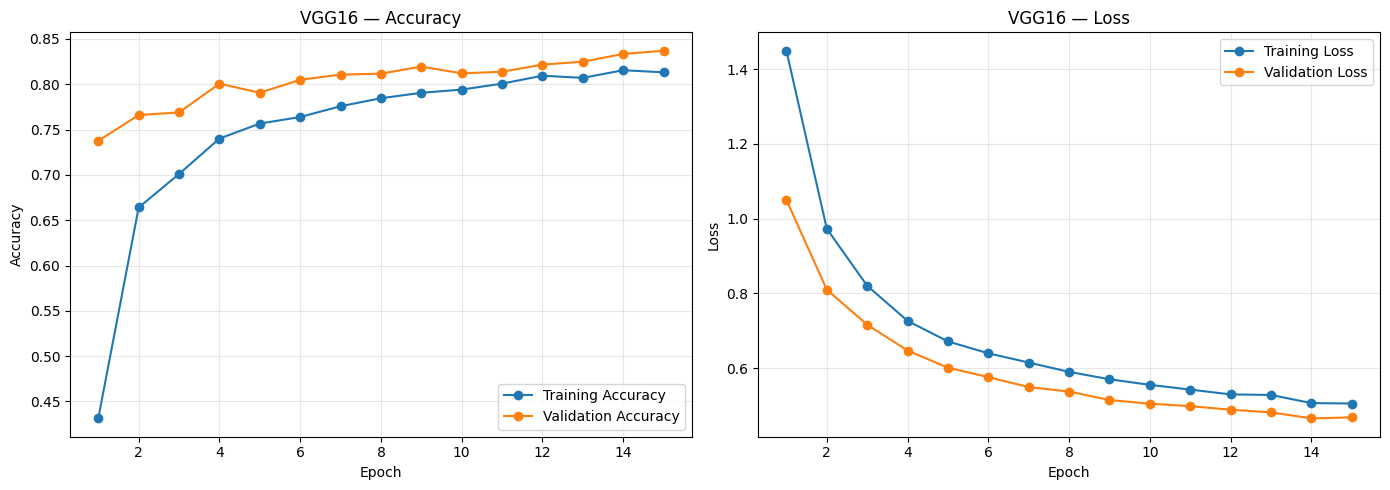

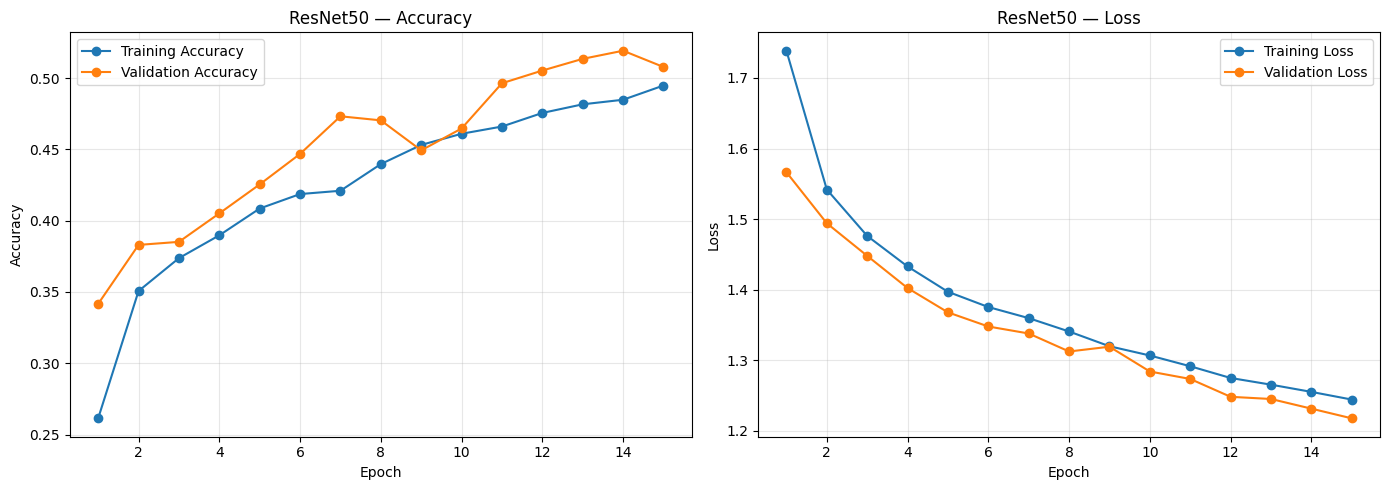

In [22]:
# ------------------------------------------------------------
# Plot training/validation accuracy and loss curves
# ------------------------------------------------------------
def plot_history(history, model_name):
    hist = history.history
    epochs_range = range(1, len(hist["accuracy"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs_range, hist["accuracy"], label="Training Accuracy", marker="o")
    axes[0].plot(epochs_range, hist["val_accuracy"], label="Validation Accuracy", marker="o")
    axes[0].set_title(f"{model_name} — Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Loss
    axes[1].plot(epochs_range, hist["loss"], label="Training Loss", marker="o")
    axes[1].plot(epochs_range, hist["val_loss"], label="Validation Loss", marker="o")
    axes[1].set_title(f"{model_name} — Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(vgg16_history, "VGG16")
plot_history(resnet50_history, "ResNet50")


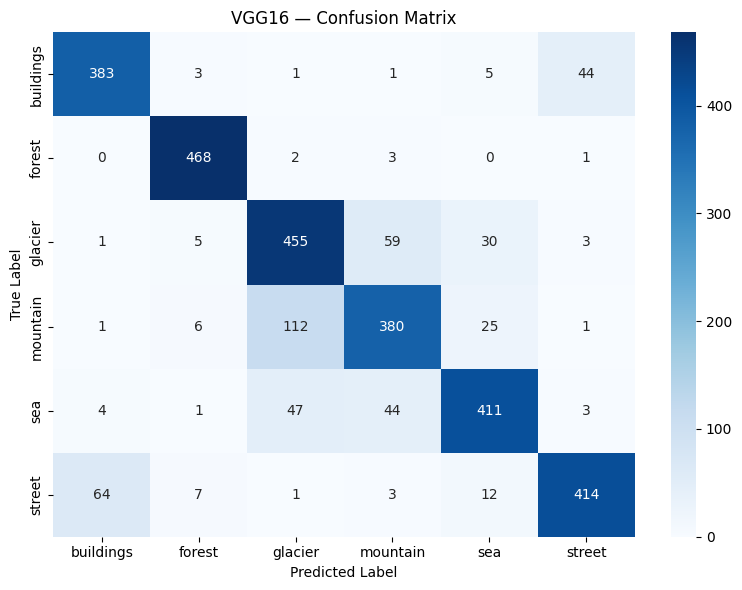

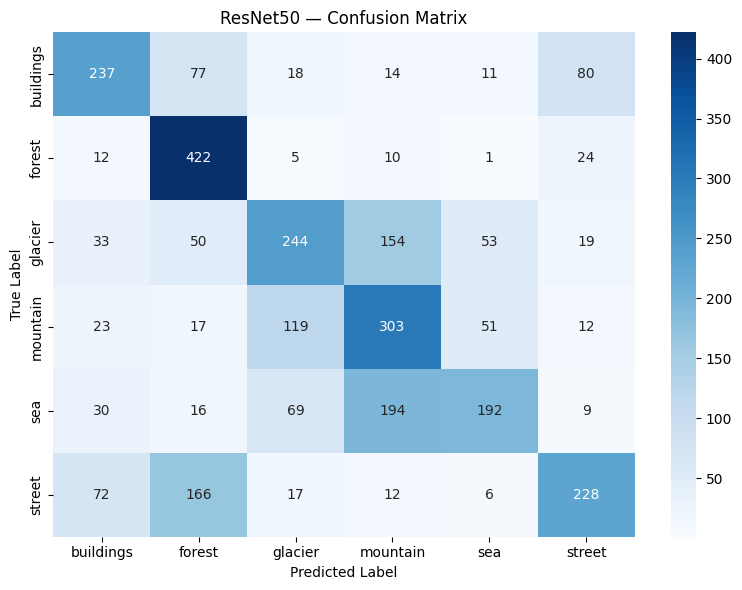

In [23]:
# ------------------------------------------------------------
# Confusion matrix heatmaps
# ------------------------------------------------------------
def plot_confusion_matrix(cm, class_names, model_name):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{model_name} — Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(vgg16_results["confusion_matrix"], CLASS_NAMES, "VGG16")
plot_confusion_matrix(resnet50_results["confusion_matrix"], CLASS_NAMES, "ResNet50")


## 10. Performance Comparison

The table and charts below summarize **Accuracy**, **Precision**, **Recall**, **F1 Score**, and **Training Time** for both models side by side.


In [24]:
# ------------------------------------------------------------
# Build comparison table
# ------------------------------------------------------------
comparison_df = pd.DataFrame([
    {
        "Model": "VGG16",
        "Accuracy": vgg16_results["accuracy"],
        "Precision": vgg16_results["precision"],
        "Recall": vgg16_results["recall"],
        "F1 Score": vgg16_results["f1_score"],
        "Training Time (s)": round(vgg16_training_time, 2),
        "Training Time (min)": round(vgg16_training_time / 60, 2),
        "Total Parameters": vgg16_model.count_params(),
    },
    {
        "Model": "ResNet50",
        "Accuracy": resnet50_results["accuracy"],
        "Precision": resnet50_results["precision"],
        "Recall": resnet50_results["recall"],
        "F1 Score": resnet50_results["f1_score"],
        "Training Time (s)": round(resnet50_training_time, 2),
        "Training Time (min)": round(resnet50_training_time / 60, 2),
        "Total Parameters": resnet50_model.count_params(),
    },
])

comparison_df_display = comparison_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1 Score"]:
    comparison_df_display[col] = comparison_df_display[col].map(lambda x: f"{x:.4f}")

comparison_df_display


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (s),Training Time (min),Total Parameters
0,VGG16,0.8370,0.8385,0.8370,0.8368,2486.93,41.45,14847558
1,ResNet50,0.5420,0.5527,0.5420,0.5326,2340.35,39.01,24113798


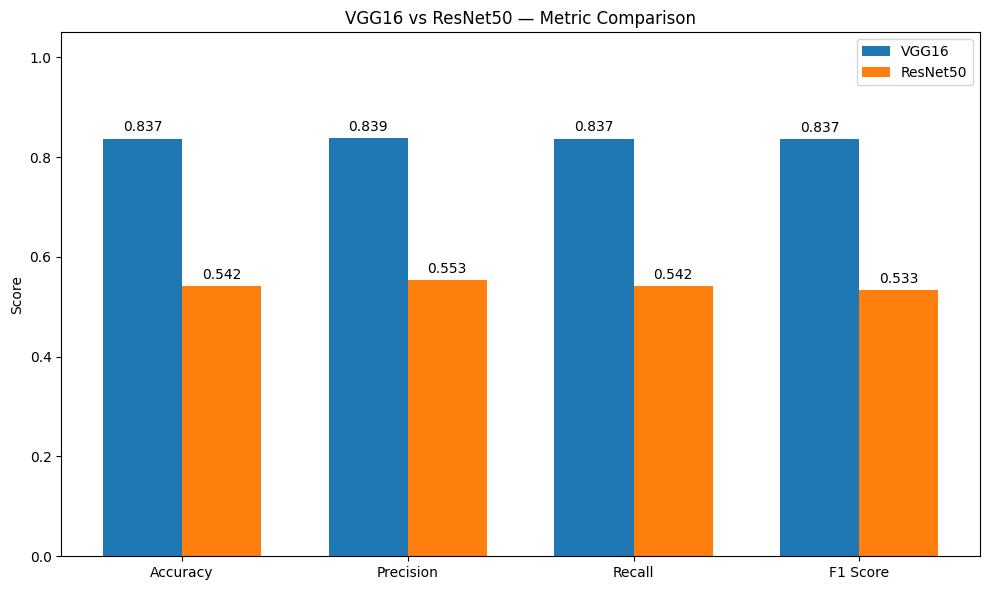

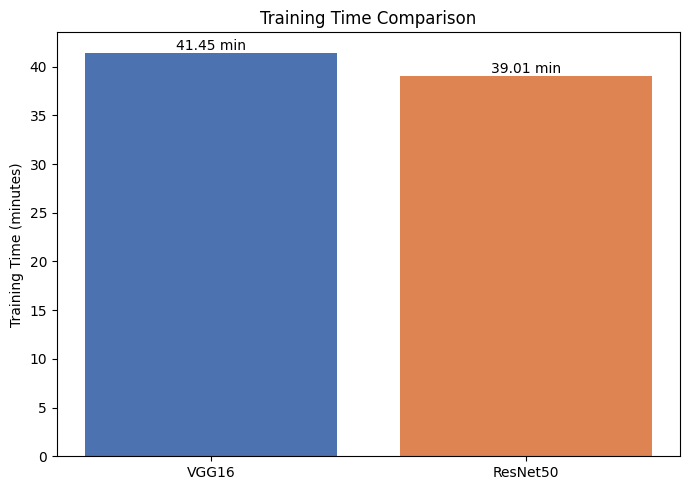

In [25]:
# ------------------------------------------------------------
# Visual comparison: grouped bar chart of metrics
# ------------------------------------------------------------
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
vgg_vals = comparison_df.loc[comparison_df.Model == "VGG16", metrics].values.flatten()
resnet_vals = comparison_df.loc[comparison_df.Model == "ResNet50", metrics].values.flatten()

bars1 = ax.bar(x - width / 2, vgg_vals, width, label="VGG16")
bars2 = ax.bar(x + width / 2, resnet_vals, width, label="ResNet50")

ax.set_ylabel("Score")
ax.set_title("VGG16 vs ResNet50 — Metric Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3)
ax.bar_label(bars2, fmt="%.3f", padding=3)
plt.tight_layout()
plt.show()

# Training time comparison
plt.figure(figsize=(7, 5))
bars = plt.bar(comparison_df["Model"], comparison_df["Training Time (min)"],
                color=["#4C72B0", "#DD8452"])
plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.bar_label(bars, fmt="%.2f min")
plt.tight_layout()
plt.show()


## Discussion

### Which model performs better?

Based on the results obtained in this project, VGG16 performed better than ResNet50. VGG16 achieved an accuracy of 83.70% and an F1 Score of 0.8368, while ResNet50 achieved an accuracy of 54.20% and an F1 Score of 0.5326. This indicates that VGG16 was able to classify the six image categories more accurately and produced better overall performance on the test dataset.

### Which model trains faster?

ResNet50 trained slightly faster than VGG16. The training time for ResNet50 was approximately 39.01 minutes, while VGG16 took about 41.45 minutes. Although ResNet50 required less training time, its prediction performance was significantly lower than VGG16 in this experiment.

### Overall Observation

For this dataset and training setup, VGG16 provided the best balance between accuracy and reliability. While ResNet50 completed training faster, VGG16 produced much better classification results and was therefore selected as the best-performing model.
* **Advantages / disadvantages:**

| | VGG16 | ResNet50 |
|---|---|---|
| **Architecture** | Simple, uniform stack of 3x3 convs | Residual ("skip-connection") blocks, bottleneck design |
| **Parameters** | ~138M (very large) | ~25.6M (much more parameter-efficient) |
| **Depth** | 16 weight layers | 50 weight layers (deeper, enabled by residual connections) |
| **Training/Inference speed** | Slower, heavier memory footprint | Generally faster, lighter |
| **Feature quality for transfer learning** | Strong, very well-studied baseline | Often stronger due to deeper hierarchical features |
| **Ease of understanding** | Very simple to reason about | Slightly more complex (skip connections, batch norm) |

Both architectures remain excellent transfer-learning backbones; the "best" choice in practice depends on the trade-off between accuracy, inference latency, and deployment memory constraints for the target application.


## 11. Prediction on New Images

Below is a reusable function that loads **any image** (a custom uploaded image, or one taken from `seg_pred/`), preprocesses it the same way as the training pipeline, and predicts its class using a chosen trained model. It displays the image alongside the **predicted class** and **confidence score**.



In [27]:
# ------------------------------------------------------------
# Prediction function for a single image
# ------------------------------------------------------------
def predict_image(image_path, model, class_names, img_size=(224, 224)):
    '''Load an image, preprocess it, and return (predicted_class, confidence, raw_probs).'''
    img = load_img(image_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0          # normalize the same way as training
    img_array = np.expand_dims(img_array, axis=0)   # add batch dimension

    probs = model.predict(img_array, verbose=0)[0]
    predicted_idx = int(np.argmax(probs))
    predicted_class = class_names[predicted_idx]
    confidence = float(probs[predicted_idx])

    return predicted_class, confidence, probs


def show_prediction(image_path, model, class_names, model_name="Model"):
    predicted_class, confidence, probs = predict_image(image_path, model, class_names)

    img = load_img(image_path)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{model_name} Prediction: {predicted_class}\nConfidence: {confidence * 100:.2f}%")
    plt.show()

    return predicted_class, confidence


Running predictions on 3 demo image(s) using the BEST model (VGG16)...



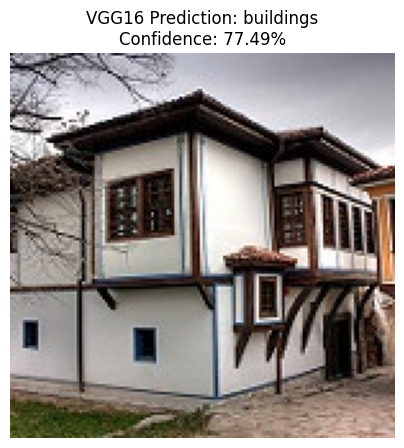

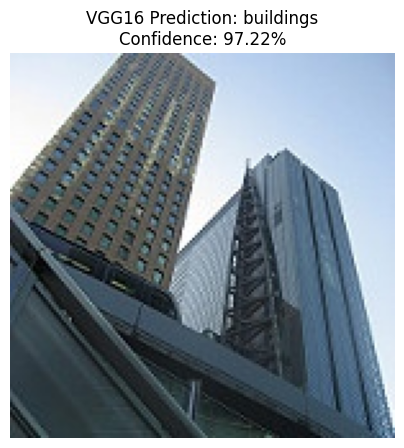

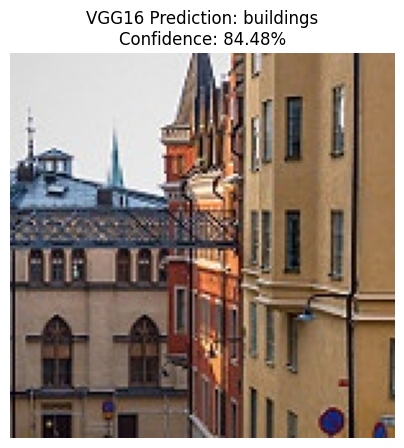

In [28]:
# ------------------------------------------------------------
# Demo: predict on a handful of sample images
# (Replace `custom_image_path` with your own uploaded image path to
#  test a real custom image.)
# ------------------------------------------------------------
demo_image_paths = []

if os.path.exists(PRED_DIR):
    pred_files = [f for f in os.listdir(PRED_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    demo_image_paths = [os.path.join(PRED_DIR, f) for f in random.sample(pred_files, min(3, len(pred_files)))]
else:
    # Fallback: use a couple of test-set images if seg_pred isn't available
    for cls in CLASS_NAMES[:3]:
        cls_dir = os.path.join(TEST_DIR, cls)
        f = random.choice(os.listdir(cls_dir))
        demo_image_paths.append(os.path.join(cls_dir, f))

print(f"Running predictions on {len(demo_image_paths)} demo image(s) using the BEST model "
      f"({'ResNet50' if resnet50_results['f1_score'] >= vgg16_results['f1_score'] else 'VGG16'})...\n")

best_model, best_model_name = (
    (resnet50_model, "ResNet50") if resnet50_results["f1_score"] >= vgg16_results["f1_score"]
    else (vgg16_model, "VGG16")
)

for path in demo_image_paths:
    show_prediction(path, best_model, CLASS_NAMES, model_name=best_model_name)


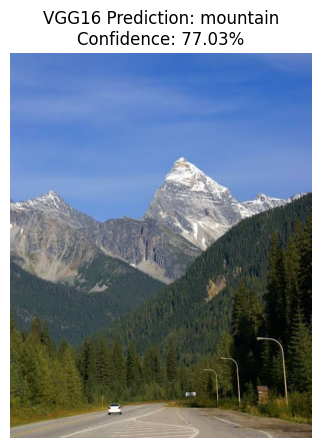

In [30]:
custom_image_path = "/kaggle/input/datasets/syedairmishfatima/images/images.jpg"  # e.g. "/kaggle/input/my-uploaded-images/my_photo.jpg"

if custom_image_path and os.path.exists(custom_image_path):
    show_prediction(custom_image_path, best_model, CLASS_NAMES, model_name=best_model_name)
else:
    print("Set `custom_image_path` above to the path of an uploaded image to test it here. "
          "(Skipped — no custom image path provided.)")


# 12. Conclusion

In this project, the [Intel Image Classification dataset](https://www.kaggle.com/datasets/puneet6060/intel-image-classification) was used to classify images into 6 classes: **buildings, forest, glacier, mountain, sea, and street**. Before training, the images were cleaned, resized to **224 × 224**, normalized, and augmented using rotation, zoom, and horizontal flipping to improve the model's ability to generalize.

Two transfer learning models, **VGG16** and **ResNet50**, were implemented using pre-trained ImageNet weights. A custom classification head was added to both models, and they were trained and evaluated using the same dataset and training configuration.

## Results Summary

The evaluation results showed that **VGG16 outperformed ResNet50** on this dataset.

* **VGG16 Accuracy:** 83.70%

* **VGG16 F1 Score:** 0.8368

* **ResNet50 Accuracy:** 54.20%

* **ResNet50 F1 Score:** 0.5326

Although **ResNet50 trained slightly faster**, VGG16 achieved significantly better classification performance and produced more accurate predictions across all six classes.

## Key Observations

* Transfer learning proved to be an effective approach for image classification.
* Data augmentation helped improve model generalization and reduced overfitting.
* Some classes with similar visual features, such as **glacier** and **mountain**, were more difficult to classify correctly.
* VGG16 produced more reliable and consistent results compared to ResNet50 in this experiment.
* ResNet50 required slightly less training time but did not achieve the same level of accuracy as VGG16.

## Final Conclusion

Based on the obtained results, **VGG16 was selected as the best-performing model for this project**. The model achieved higher Accuracy, Precision, Recall, and F1 Score, making it more suitable for the Intel Image Classification dataset. This project demonstrates how pre-trained deep learning models can successfully solve image classification problems while reducing training time and computational cost compared to training a model from scratch.
